# Uninfected Figures

### Setup and Load Data

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams
%matplotlib inline
import scipy.sparse
import cmasher as cmr
from natsort import natsorted
import sys 
import os
sys.path.append(os.path.abspath(".\jl_modules"))
import sc_module as sm
from collections import OrderedDict
import decoupler as dc

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80)

# *** Input File ***  h5 file  
sample_name = r'uninfected'
h5_file_path = r'./data/'
clustered_file = h5_file_path + sample_name + '.h5ad'
marker_dictionary_fn = "./data/marker_dictionary.pkl"

### Read data

In [2]:
# clustered data
adata = sc.read_h5ad(clustered_file)
adata.uns['log1p']["base"] = None    # bug fix

print(adata.obs['sample'].value_counts())
print()
print('X matrix is sparse:', scipy.sparse.issparse(adata.X))
print('X size =', adata.X.shape)

sample
control3    7395
control2    6385
control1    2185
Name: count, dtype: int64

X matrix is sparse: False
X size = (15965, 21870)


### Set up

In [3]:
cluster_type = "my_clust_1"

#### Cell Type Dictionary

In [4]:
annotation_dict= {
'0': 'CAP1',
'12': 'CAP2',
'21': 'VEC',
'17': 'AEC',
'28': 'LEC',

'14': 'Ciliated',
'5': 'Secretory',
'1': 'AT1',
'2': 'AT2',

'3': 'AF1',
'9': 'AF2',
'20': 'Pericyte',
'26': 'SMC',

'18': 'Mesothelial',

'8': 'B1',
    
'23b': 'Treg',
'11': 'Tnaive',

'24': 'NK',
    
'10': 'AM',
'15b': 'M-C1q',
'25': 'iMon',
'15': 'DC',
'15c': 'pDC',
'22': 'N1',
}

# Add cell type column based on annotation
adata.obs['cell_type_edit'] = [annotation_dict[clust] for clust in adata.obs[cluster_type]]

# Error checking
dict_list = list(annotation_dict.keys())
adata_list = list(adata.obs['my_clust_1'].unique())
print('Keys in dictionary not in adata:', [item for item in dict_list if item not in adata_list] )
print('Keys in adata not in dictionary:', [item for item in adata_list if item not in dict_list] )

Keys in dictionary not in adata: []
Keys in adata not in dictionary: []


#### Cell Type Colors

In [5]:
pal1 = {
'CAP1': '#D1F8B0',
'CAP2': '#E59637',
'AEC': '#cb3329',
'VEC': '#FCCDE5',
'LEC': '#74008B',
'Ciliated': '#A473B0',
'Secretory': '#158364',
'AT1': '#79BAFF',
'AT2': '#FDB462',
'AT2-t1': '#80B1D3',
'AT2-t2': '#FB8072',
'AF1': '#A1DEC6',
'AF2': '#33A02C',
'Pericyte': '#526FBD',
'SMC': '#99DDFF',
'Mesothelial': '#FF5A48',
'B1': '#CAFFFE',
'B2': '#9B7DB7',
'NK': '#ce4432',
'Th1': '#92cde0',
'Tnaive': '#EE8866',
'Tex': '#98B299',
'Treg': '#addea2',
'AM': '#4D8CC4',
'M-C1q': '#FF6DB6',
'M-t1': '#CCEBC5',
'M-t2': '#FFFFB3',
'M-lc': '#44BB99',
'iMon': '#FF5A48',
'DC': '#4e9cbd',
'pDC': '#E04E29',
'N1': '#C2AA36',
'N2': '#BEBADA',
}

## Figures

#### Label cell types

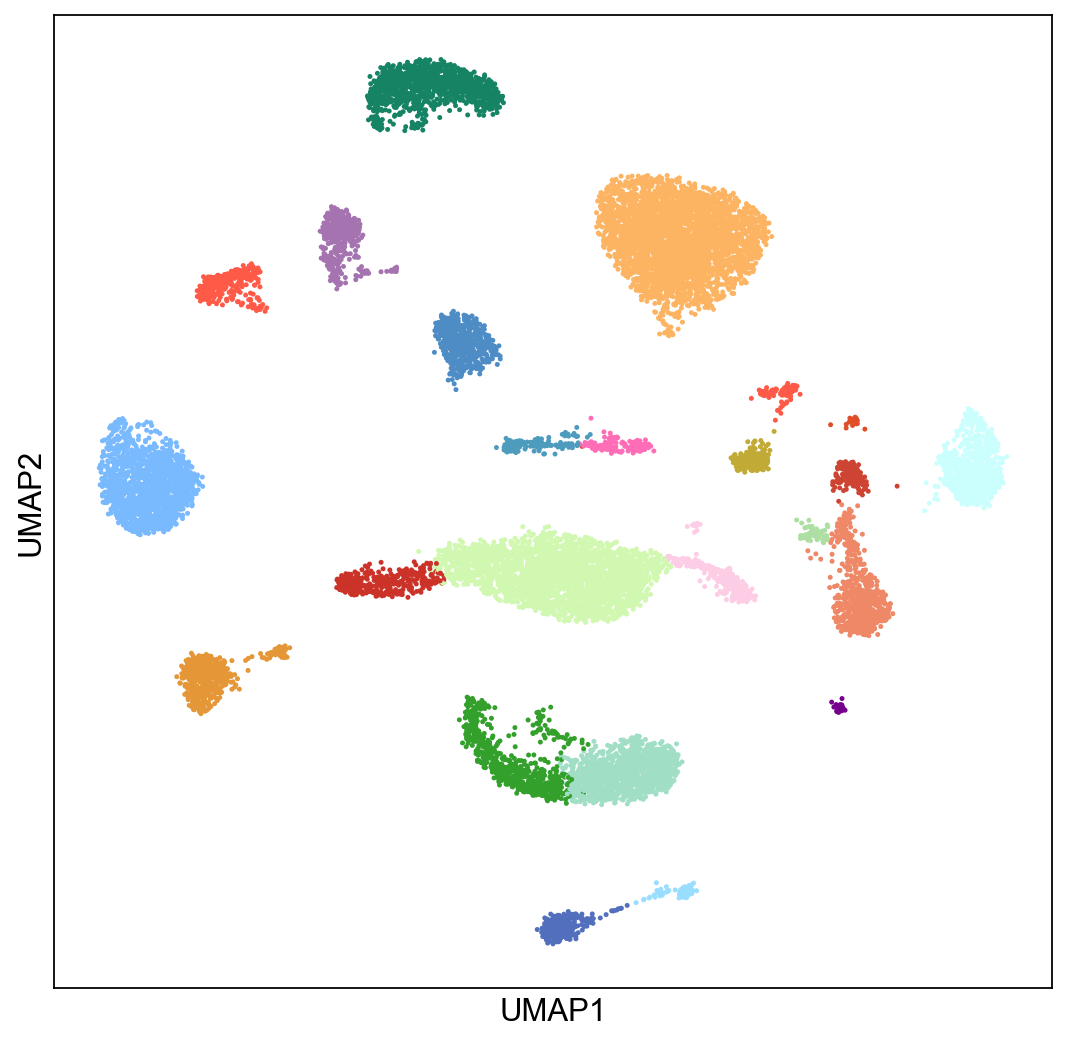

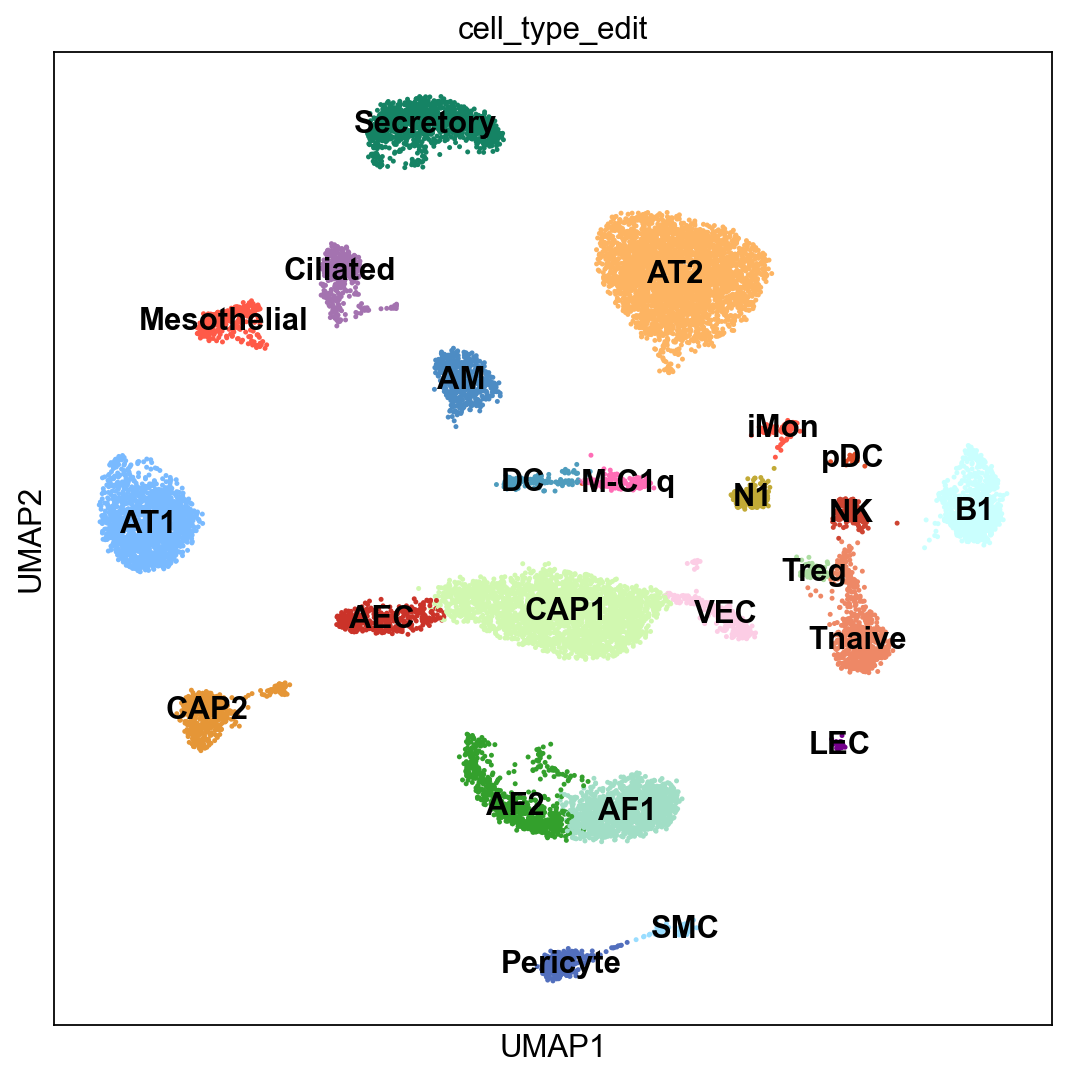

In [14]:
rcParams['figure.figsize'] = 8, 8
sc.pl.umap(adata,color='cell_type_edit',s=20, palette=pal1, title='', legend_loc='none')
sc.pl.umap(adata, color='cell_type_edit', size=20, legend_loc='on data', palette=pal1)

### Cell Numbers

In [7]:
df = adata.obs.groupby("sample", observed=False)[['cell_type_edit']].value_counts()
df = df.reset_index()
df = df.pivot(index='sample', columns='cell_type_edit', values=["count"])

df.columns = df.columns.droplevel(0)
df = df.reset_index()
df = df.set_index('sample')
df.index.name = None 
df.columns.name = None

df.T

,control1,control2,control3
AEC,64,183,103
AF1,152,498,652
AF2,64,300,338
AM,89,321,142
AT1,207,557,813
AT2,463,1294,1627
B1,93,310,365
CAP1,372,1131,1147
CAP2,105,235,220
Ciliated,65,137,205


### Load and Check Annotation Dictionary

In [8]:
# Load the dictionary from the file
marker_dict = sm.load_dictionary_from_file(marker_dictionary_fn)
# marker_dict

In [9]:
marker_dict, msg = sm.validate_dict(marker_dict, adata.var_names)
print(msg)
my_cell_types = list(marker_dict.keys())

gene_dict = marker_dict
# add cell type scores to .obs
for key in gene_dict:
    genes = gene_dict[key]
    markers_df = adata[:,genes].to_df()
    for column in markers_df.columns:
        n = 1 # min max normalization, use average of n values to calculate min max
        markers_df[column] = (markers_df[column] - markers_df[column].nsmallest(n).mean()) 
        markers_df[column] = markers_df[column] / markers_df[column].nlargest(n).mean()
    markers_df[key] = markers_df.mean(axis=1)
    adata.obs[key] = markers_df[key]

#### Order for Figures

In [10]:
celltype_order = ['AM', 'M-C1q', 'iMon', 'DC', 'pDC', 'N1',
                'B1', 'Tnaive', 'Treg', 'NK', 
                'Mesothelial', 'AF1', 'AF2', 'Pericyte', 'SMC', 
                'CAP1', 'CAP2', 'AEC', 'VEC', 'LEC', 
                'AT1', 'AT2', 'Ciliated', 'Secretory', 
                 ] 

adata_cell_types = adata.obs['cell_type_edit'].unique()

print('Cell types in list not in adata:', [item for item in celltype_order if item not in adata_cell_types] )
print('Cell types in adata not in list:', [item for item in adata_cell_types if item not in celltype_order] )

Cell types in list not in adata: []
Cell types in adata not in list: []


#### Superset cell types, all clusters

In [11]:
plot_list = ['Myeloid','Lymphoid', 'Mesenchyme','Endothelial', 'Epithelial']

# check if in my_cell_types
subset_cell_types = [x for x in my_cell_types if x in plot_list]

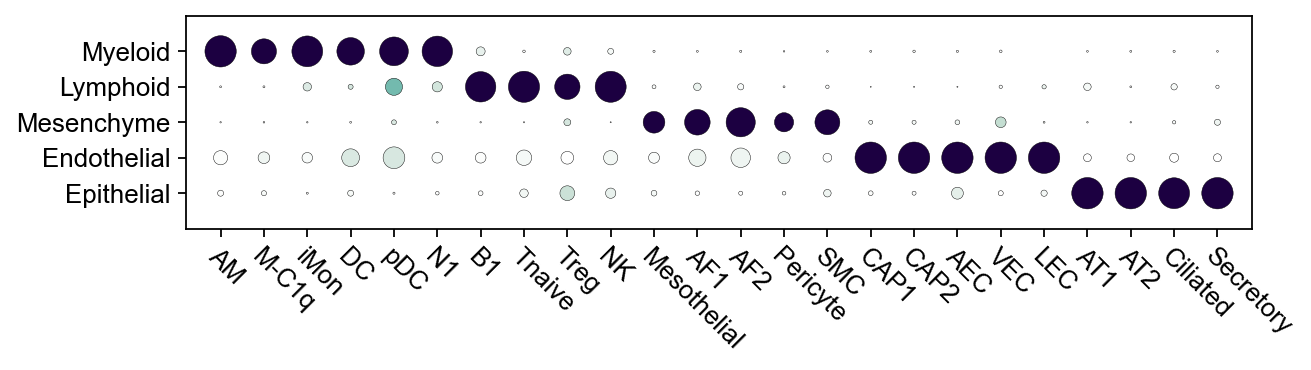

In [12]:
standard_scale='var'

dp = sc.pl.dotplot(adata, subset_cell_types, groupby='cell_type_edit', 
              categories_order=celltype_order, swap_axes=True, cmap=cmr.ocean_r, 
              standard_scale=standard_scale, show=False, return_fig=True)

dp.legend(show=False)
ax = dp.get_axes()["mainplot_ax"]
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left", rotation_mode="anchor")
plt.show()

#### All cell types, all clusters

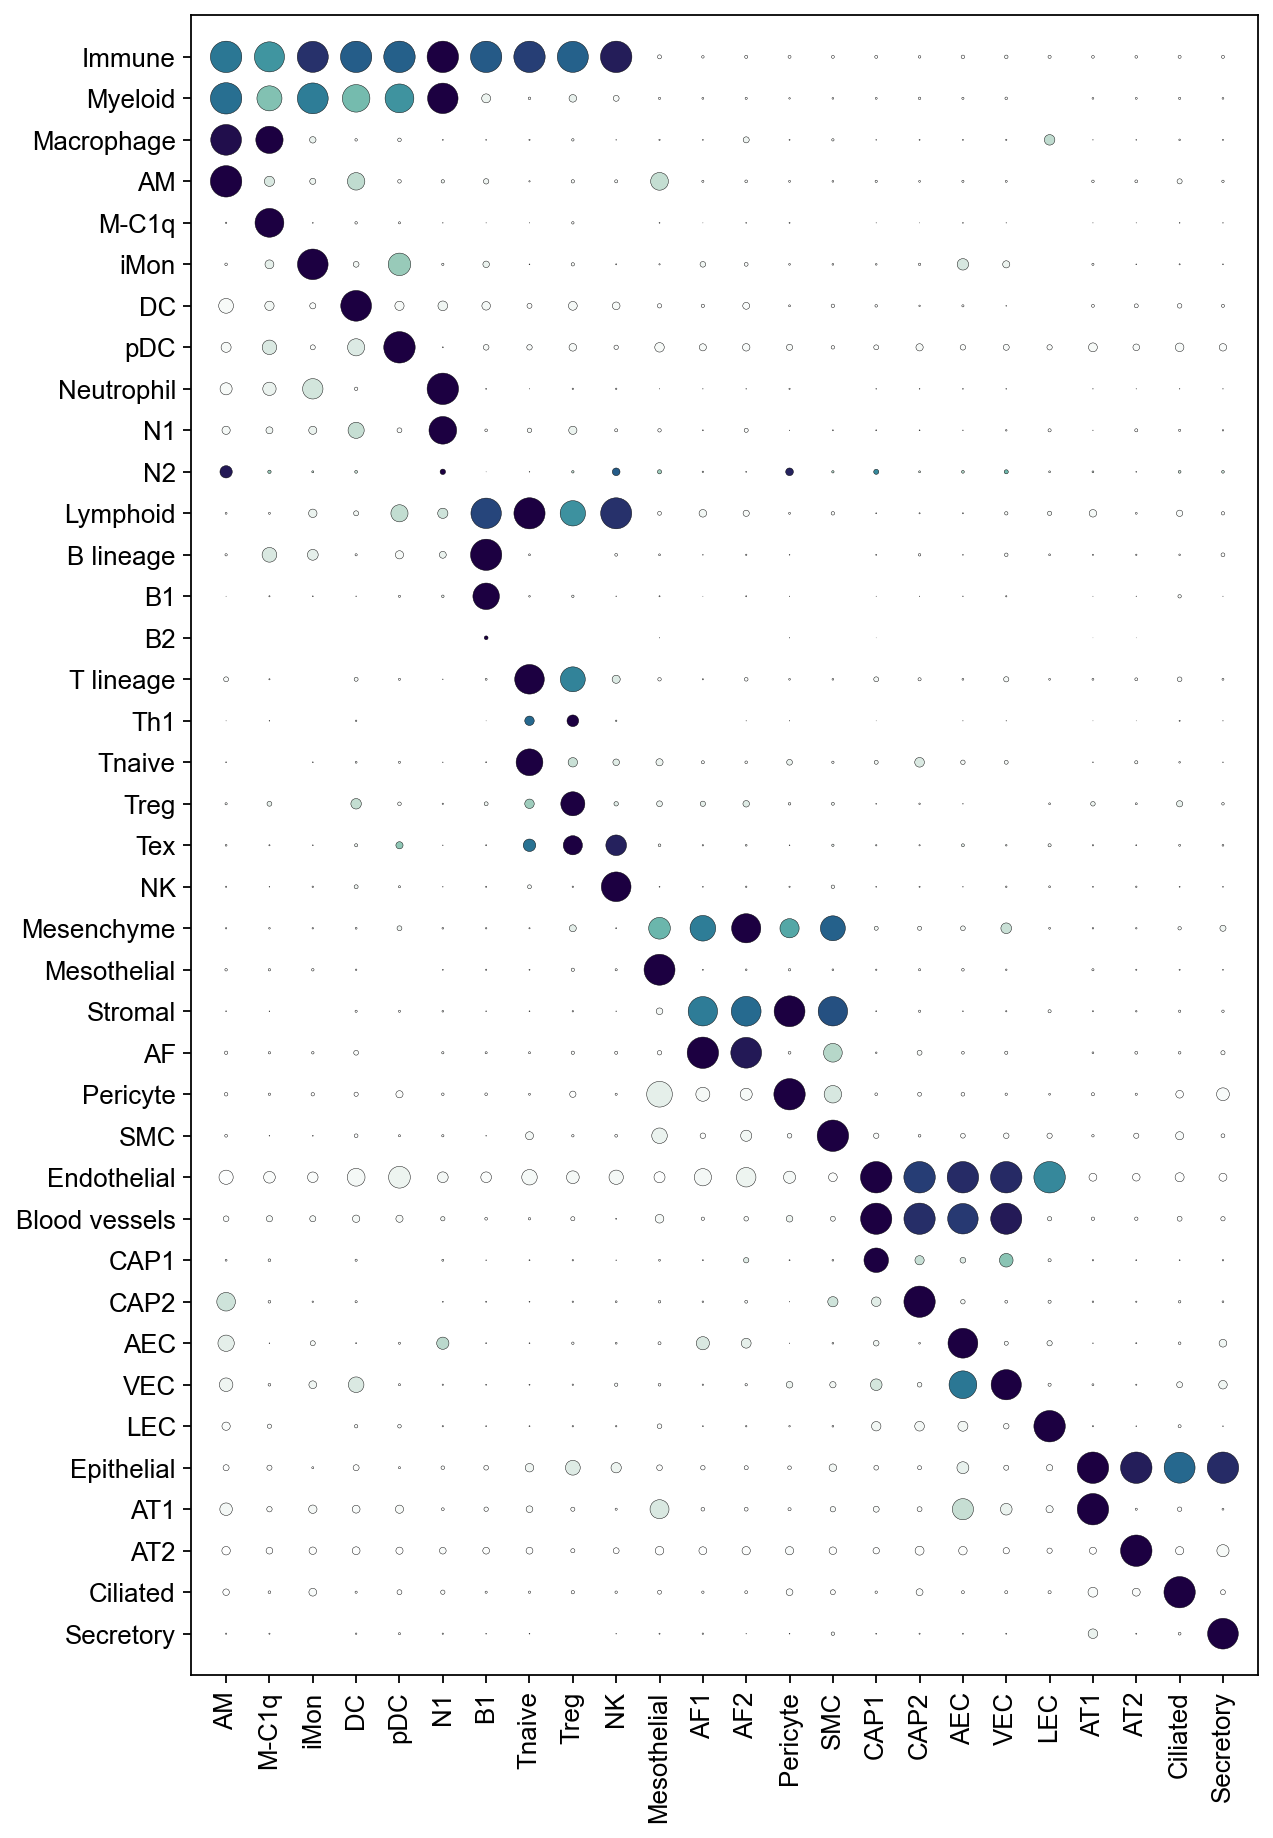

In [13]:
standard_scale='var'

dp = sc.pl.dotplot(adata, my_cell_types, groupby='cell_type_edit', categories_order=celltype_order,
            standard_scale=standard_scale, swap_axes=True, cmap=cmr.ocean_r, 
            show=False, return_fig=True)
dp.legend(show=False).show()